##<font color='blue'>----------**Encoder for POS tagging**-----------</font>

**Tutorial 4 Outline: Transformer Models**

•	Download the PennTreebank dataset from torchtext.datasets for parts of speech (POS) tagging (train, valid and test partitions).

•	Show some samples from the dataset and the corresponding labels (i.e. POS tags for each word).  

•	Tokenize the dataset (you can use the BERT tokenizer from Hugging Face’s transformer library.  

•	Show the class distribution of the dataset.  

•	Design the transformer encoder layer as proposed in Attention Is All You Need, using PyTorch’s nn.MultiHeadAttention() position wise feedforward neural network, residudal connection and nn.LayerNorm.

•	Design a transformer model using nn.Embedding (for token embedding), sinusoidal positional encoding and a few transformer encoder layers (as designed in the previous step).

•	Show the summary of the transformer model you designed.  

•	Train the transformer model using categorical cross entropy loss and Adam optimizer. Show the training and validation loss plots.

•	Evaluate the model on the test set and report the performance (accuracy, precision, recall).  

•	Show some test samples and corresponding POS predictions

•	Design a transfer-learning model with pre-trained BERT transformer encoder (available from the transformer library) for POS tagging. For this purpose add a fully connected layer for classification on the representation learned by the BERT encoder, i.e. use BERT as a pretrained (frozen) feature extractor.

•	Train the  BERT-based transfer learning model and show the variation of the training and validation losses.  

•	Evaluate the model trained with transfer learning on the test set and report the performance (accuracy, precision, recall)

•	Show some test samples and corresponding POS predictions (pick the same samples as for the model trained from scratch, i.e. without transfer learning).  


In [ ]:
# installation of required packages - portallocker, torchtext, torchinfo,---
!pip -q install portalocker
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q torchtext==0.15.2
!pip install -q torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 45.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 33.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 58.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.7/848.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

In [ ]:
# import random
# import numpy as np
# import torch

# SEED = 1234

# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# torch.backends.cudnn.deterministic = True

**Task:**

Download the PennTreebank dataset from torchtext.datasets for parts of speech (POS) tagging (train, valid and test partitions).

In [ ]:
from torchtext.datasets import PennTreebank
train_iter = PennTreebank(split='train')
valid_iter = PennTreebank(split='valid')
test_iter = PennTreebank(split='test')

**Task:**

Show some samples from the dataset and the corresponding labels (i.e. POS tags for each word).

**NOTE:** The ```torchtext PennTreebank``` only consist collection of sentences without POS tags.

In [ ]:
train_data = list(train_iter)
print(train_data[0])

aer banknote berlitz calloway centrust cluett fromstein gitano guterman hydro-quebec ipo kia memotec mlx nahb punts rake regatta rubens sim snack-food ssangyong swapo wachter


In [ ]:
train_data[0:5]

['aer banknote berlitz calloway centrust cluett fromstein gitano guterman hydro-quebec ipo kia memotec mlx nahb punts rake regatta rubens sim snack-food ssangyong swapo wachter',
 'pierre <unk> N years old will join the board as a nonexecutive director nov. N',
 'mr. <unk> is chairman of <unk> n.v. the dutch publishing group',
 'rudolph <unk> N years old and former chairman of consolidated gold fields plc was named a nonexecutive director of this british industrial conglomerate',
 'a form of asbestos once used to make kent cigarette filters has caused a high percentage of cancer deaths among a group of workers exposed to it more than N years ago researchers reported']

In [ ]:
import spacy

# Load spaCy model (run: "!python -m spacy download en_core_web_sm" if not installed)
nlp = spacy.load("en_core_web_sm")

# Convert sentences to word/POS format
def convert_to_word_pos_format(sentences, num_sentences=10):
    formatted = []
    for sentence in sentences[:num_sentences]:
        doc = nlp(sentence)
        word_pos = ' '.join([f"{token.text}/{token.pos_}" for token in doc])
        formatted.append(word_pos)
    return formatted

formatted_data = convert_to_word_pos_format(train_data, num_sentences=10)
print(formatted_data)

['aer/PROPN banknote/PROPN berlitz/PROPN calloway/PROPN centrust/PROPN cluett/PROPN fromstein/PROPN gitano/PROPN guterman/PROPN hydro/PROPN -/PUNCT quebec/PROPN ipo/PROPN kia/PROPN memotec/PROPN mlx/PROPN nahb/PROPN punts/PROPN rake/VERB regatta/NOUN rubens/VERB sim/ADJ snack/NOUN -/PUNCT food/NOUN ssangyong/ADJ swapo/ADJ wachter/NOUN', 'pierre/NOUN </PUNCT unk/X >/X N/NUM years/NOUN old/ADJ will/AUX join/VERB the/DET board/NOUN as/ADP a/DET nonexecutive/ADJ director/NOUN nov/PROPN ./PROPN N/PROPN', 'mr/PROPN ./PROPN </X unk/INTJ >/X is/AUX chairman/NOUN of/ADP </X unk/PROPN >/X n.v/PROPN ./PUNCT the/DET dutch/PROPN publishing/NOUN group/NOUN', 'rudolph/PROPN </X unk/INTJ >/X N/NUM years/NOUN old/ADJ and/CCONJ former/ADJ chairman/NOUN of/ADP consolidated/ADJ gold/NOUN fields/NOUN plc/PROPN was/AUX named/VERB a/DET nonexecutive/ADJ director/NOUN of/ADP this/DET british/ADJ industrial/ADJ conglomerate/NOUN', 'a/DET form/NOUN of/ADP asbestos/NOUN once/ADV used/VERB to/PART make/VERB kent/

In [ ]:
# function to extract words and tags
def extract_samples(data, num_samples=10):
    for sentence in data[:num_samples]:
        words, tags = [], []
        for token in sentence.split():
            if '/' in token:
                word, tag = token.rsplit('/', 1)
                words.append(word)
                tags.append(tag)
        print("Words: ", words)
        print("Tags:  ", tags)
        print("-" * 256)

extract_samples(formatted_data, num_samples=10)

Words:  ['aer', 'banknote', 'berlitz', 'calloway', 'centrust', 'cluett', 'fromstein', 'gitano', 'guterman', 'hydro', '-', 'quebec', 'ipo', 'kia', 'memotec', 'mlx', 'nahb', 'punts', 'rake', 'regatta', 'rubens', 'sim', 'snack', '-', 'food', 'ssangyong', 'swapo', 'wachter']
Tags:   ['PROPN', 'PROPN', 'PROPN', 'PROPN', 'PROPN', 'PROPN', 'PROPN', 'PROPN', 'PROPN', 'PROPN', 'PUNCT', 'PROPN', 'PROPN', 'PROPN', 'PROPN', 'PROPN', 'PROPN', 'PROPN', 'VERB', 'NOUN', 'VERB', 'ADJ', 'NOUN', 'PUNCT', 'NOUN', 'ADJ', 'ADJ', 'NOUN']
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Words:  ['pierre', '<', 'unk', '>', 'N', 'years', 'old', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'nov', '.', 'N']
Tags:   ['NOUN', 'PUNCT', 'X', 'X', 'NUM', 'NOUN', 'ADJ', 'AUX', 'VERB', 'DET

**Task:**

Tokenize the dataset (you can use the BERT tokenizer from Hugging Face’s transformer library).  

In [ ]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

sample_sentences = train_data[:5]

# Tokenize and show subwords
for i, sentence in enumerate(sample_sentences):
    print(f"\n Sentence {i+1}: {sentence}\n")

    # Get subword tokens
    subword_tokens = tokenizer.tokenize(sentence)
    print("Subword Tokens:")
    print(subword_tokens)

    # Get corresponding input IDs
    input_ids = tokenizer.convert_tokens_to_ids(subword_tokens)
    print("\nInput IDs:")
    print(input_ids)
    print("-" * 100)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.11/dist-package


 Sentence 1: aer banknote berlitz calloway centrust cluett fromstein gitano guterman hydro-quebec ipo kia memotec mlx nahb punts rake regatta rubens sim snack-food ssangyong swapo wachter

Subword Tokens:
['ae', '##r', 'bank', '##note', 'be', '##rl', '##itz', 'call', '##owa', '##y', 'cent', '##rus', '##t', 'clue', '##tt', 'from', '##stein', 'gi', '##tan', '##o', 'gut', '##erman', 'hydro', '-', 'quebec', 'ip', '##o', 'kia', 'memo', '##tec', 'ml', '##x', 'nah', '##b', 'punt', '##s', 'rake', 'regatta', 'ruben', '##s', 'sim', 'snack', '-', 'food', 'ss', '##ang', '##yon', '##g', 'swap', '##o', 'wa', '##cht', '##er']

Input IDs:
[29347, 2099, 2924, 22074, 2022, 12190, 8838, 2655, 21293, 2100, 9358, 7946, 2102, 9789, 4779, 2013, 8602, 21025, 5794, 2080, 9535, 18689, 18479, 1011, 5447, 12997, 2080, 27005, 24443, 26557, 19875, 2595, 20976, 2497, 18975, 2015, 26008, 26848, 19469, 2015, 21934, 19782, 1011, 2833, 7020, 5654, 14001, 2290, 19948, 2080, 11333, 10143, 2121]
--------------------------

**Task:**

Show the class distribution of the dataset.  

In [ ]:
from collections import Counter

# function to get POS tag distribution for a given split
def get_pos_distribution(split_name):
    dataset_iter = PennTreebank(split=split_name)
    data = list(dataset_iter)

    pos_counter = Counter()

    for sentence in data:
        doc = nlp(sentence)
        for token in doc:
            pos_counter[token.pos_] += 1

    return pos_counter

# Get distributions for all splits
train_pos = get_pos_distribution('train')
valid_pos = get_pos_distribution('valid')
test_pos  = get_pos_distribution('test')

# most_common() sorts the tags by frequency.
print("\n Train POS Tag Distribution:")
for tag, count in train_pos.most_common():
    print(f"{tag:10s} : {count}")

print("\n Valid POS Tag Distribution:")
for tag, count in valid_pos.most_common():
    print(f"{tag:10s} : {count}")

print("\n Test POS Tag Distribution:")
for tag, count in test_pos.most_common():
    print(f"{tag:10s} : {count}")


 Train POS Tag Distribution:
NOUN       : 207349
ADP        : 104582
PROPN      : 101880
VERB       : 96132
X          : 89772
DET        : 83402
ADJ        : 62497
AUX        : 42917
PRON       : 40396
INTJ       : 33589
ADV        : 28429
PART       : 27841
CCONJ      : 26261
NUM        : 24223
SCONJ      : 14869
PUNCT      : 9565
SYM        : 7776

 Valid POS Tag Distribution:
NOUN       : 16378
ADP        : 8171
PROPN      : 7776
VERB       : 7747
X          : 6920
DET        : 6676
ADJ        : 4956
AUX        : 3329
PRON       : 3201
INTJ       : 2649
ADV        : 2384
PART       : 2269
CCONJ      : 2163
NUM        : 1985
SCONJ      : 1159
PUNCT      : 807
SYM        : 670

 Test POS Tag Distribution:
NOUN       : 18036
X          : 9461
ADP        : 9296
PROPN      : 8710
VERB       : 8365
DET        : 7364
ADJ        : 5417
AUX        : 3993
PRON       : 3614
INTJ       : 3610
ADV        : 2680
PART       : 2666
CCONJ      : 2357
NUM        : 1860
SCONJ      : 1366
PUNCT      

**Tasks:**

--->Design the transformer encoder layer as proposed in Attention Is All You Need, using PyTorch’s nn.MultiHeadAttention() position wise feedforward neural network, residudal connection and nn.LayerNorm. (note to TA: write a class for the transformer encoder).  

--->Design a transformer model using nn.Embedding (for token embedding), sinusoidal positional encoding and a few transformer encoder layers (as designed in the previous step). (note to TA: since this is a classification model, we only need the transformer encoder).  

--->Show the summary of the transformer model you designed.  

--->Train the transformer model using categorical cross entropy loss and Adam optimizer. Show the training and validation loss plots.  

--->Evaluate the model on the test set and report the performance (accuracy, precision, recall).  

--->Show some test samples and corresponding POS predictions

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchtext.datasets import PennTreebank
import spacy
from collections import Counter
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt

In [ ]:
# Load spaCy
import en_core_web_sm # a small English language model trained on web text provided by spaCy.
nlp = en_core_web_sm.load()

In [ ]:
# Load and tag sentences
def load_tagged_sentences(split):
    sentences = list(PennTreebank(split=split))
    tagged_data = []
    for sent in sentences:
        doc = nlp(sent)
        tokens = [token.text for token in doc]
        pos_tags = [token.pos_ for token in doc]
        if tokens:
            tagged_data.append((tokens, pos_tags))
    return tagged_data

train_data = load_tagged_sentences("train")
valid_data = load_tagged_sentences("valid")
test_data  = load_tagged_sentences("test")

In [ ]:
# Build vocab
word_counter = Counter()
tag_counter = Counter()
for tokens, tags in train_data:
    word_counter.update(tokens)
    tag_counter.update(tags)

word2idx = {w: i+2 for i, (w, _) in enumerate(word_counter.most_common())}
word2idx["<PAD>"] = 0
word2idx["<UNK>"] = 1
tag2idx = {t: i for i, (t, _) in enumerate(tag_counter.most_common())}
idx2tag = {i: t for t, i in tag2idx.items()}

In [ ]:
# Encode data
MAX_LEN = 64
def encode(tokens, tags):
    x = [word2idx.get(t, word2idx["<UNK>"]) for t in tokens]
    y = [tag2idx[t] for t in tags]
    if len(x) < MAX_LEN:
        pad_len = MAX_LEN - len(x)
        x += [word2idx["<PAD>"]] * pad_len
        y += [-100] * pad_len
    else:
        x = x[:MAX_LEN]
        y = y[:MAX_LEN]
    return x, y

In [ ]:
#encode_dataset that takes a dataset of sentences (each represented as a list of (tokens, tags))
# and encodes all of them into padded numeric tensors using the encode
def encode_dataset(data):
    X, Y = [], []
    for tokens, tags in data:
        x, y = encode(tokens, tags)
        X.append(x)
        Y.append(y)
    return torch.tensor(X), torch.tensor(Y)

X_train, Y_train = encode_dataset(train_data)
X_valid, Y_valid = encode_dataset(valid_data)
X_test, Y_test   = encode_dataset(test_data)

In [ ]:
# Dataset
class PosTagDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

train_dl = DataLoader(PosTagDataset(X_train, Y_train), batch_size=16, shuffle=True)
valid_dl = DataLoader(PosTagDataset(X_valid, Y_valid), batch_size=16)
test_dl  = DataLoader(PosTagDataset(X_test,  Y_test), batch_size=16)

In [ ]:
# Model components
# Transformer models to inject information about the position of each token in a sequence.
# Since Transformers process tokens in parallel (not sequentially like RNNs),
# they lack a natural sense of order—so we add positional encodings to help the model understand the sequence structure.

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [ ]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        attn_out, _ = self.self_attn(x, x, x)
        x = self.norm1(x + self.dropout(attn_out))
        # Adds the attention output back to the input (residual connection) → applies dropout → then normalizes.
        ff = self.linear2(F.relu(self.linear1(x)))
        # Applies the feed-forward network with ReLU activation between the two linear layers.
        return self.norm2(x + self.dropout(ff))
        # Again, adds the feed-forward output to the input (residual connection) → applies dropout → then normalizes.

In [ ]:
class TransformerPOS(nn.Module):
    def __init__(self, vocab_size, tagset_size, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pe = PositionalEncoding(d_model)
        self.encoder = nn.Sequential(
            *[TransformerEncoderLayer(d_model, nhead) for _ in range(num_layers)]
        )
        self.classifier = nn.Linear(d_model, tagset_size)
    def forward(self, x):
        x = self.embedding(x)
        x = self.pe(x)
        x = self.encoder(x)
        return self.classifier(x)

In [ ]:
# Initialize model
model = TransformerPOS(len(word2idx), len(tag2idx)).to("cpu")
criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

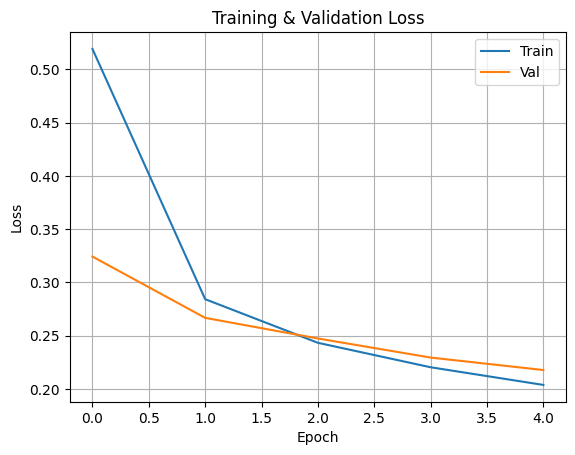

0.9255654451423878 0.920346063418552 0.9071353706257079


In [ ]:
# Train loop
train_losses, val_losses = [], []
for epoch in range(5):
    model.train()
    total_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out.view(-1, out.shape[-1]), yb.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_dl))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in valid_dl:
            out = model(xb)
            val_loss += criterion(out.view(-1, out.shape[-1]), yb.view(-1)).item()
    val_losses.append(val_loss / len(valid_dl))

# Plot loss
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Evaluation
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        preds = model(xb).argmax(dim=-1) # argmax(dim=-1) to get the index of the highest scoring tag for each token.
        for pred_seq, true_seq in zip(preds, yb):
            for p, t in zip(pred_seq, true_seq):
                if t != -100:
                    all_preds.append(p.item())
                    all_true.append(t.item())

acc = accuracy_score(all_true, all_preds)
precision, recall, _, _ = precision_recall_fscore_support(all_true, all_preds, average="macro")
print(acc, precision, recall)

In [ ]:
from sklearn.metrics import classification_report
report = classification_report(all_true, all_preds, target_names=[idx2tag[i] for i in range(len(idx2tag))])
print(report)

              precision    recall  f1-score   support

        NOUN       0.93      0.93      0.93     18006
         ADP       0.95      0.96      0.96      9282
       PROPN       0.91      0.85      0.88      8693
        VERB       0.93      0.92      0.92      8360
           X       0.94      0.95      0.95      9414
         DET       0.98      0.98      0.98      7353
         ADJ       0.89      0.91      0.90      5413
         AUX       0.98      0.97      0.97      3989
        PRON       0.94      0.91      0.92      3610
        INTJ       0.79      0.97      0.87      3590
         ADV       0.88      0.88      0.88      2679
        PART       0.92      0.95      0.93      2663
       CCONJ       1.00      0.95      0.97      2352
         NUM       0.85      0.89      0.87      1858
       SCONJ       0.87      0.82      0.84      1366
       PUNCT       0.90      0.62      0.73       891
         SYM       0.99      0.98      0.98       587

    accuracy              

In [ ]:
# Show a few test samples with predicted and true POS tags
print("\nSample Predictions with Ground Truth:\n")
num_samples_to_show = 2
test_sentences = test_data[:num_samples_to_show]
model.eval()

with torch.no_grad():
    for i, (tokens, true_tags) in enumerate(test_sentences):
        # Convert tokens to input IDs
        input_ids = torch.tensor([word2idx.get(t, word2idx["<UNK>"]) for t in tokens])
        if len(input_ids) < MAX_LEN:
            input_ids = F.pad(input_ids, (0, MAX_LEN - len(input_ids)), value=word2idx["<PAD>"])
            padded_tokens = tokens + ["<PAD>"] * (MAX_LEN - len(tokens))
            padded_true_tags = true_tags + ["<PAD>"] * (MAX_LEN - len(true_tags))
        else:
            input_ids = input_ids[:MAX_LEN]
            padded_tokens = tokens[:MAX_LEN]
            padded_true_tags = true_tags[:MAX_LEN]

        input_ids = input_ids.unsqueeze(0)  # batch dim
        preds = model(input_ids).argmax(dim=-1).squeeze().tolist()

        # Print sentence
        print(f"\nSentence {i+1}: {' '.join(tokens)}\n")
        print(f"{'Token':15s} → {'Predicted':12s} | {'True'}")
        print("-" * 50)
        for token, pred_idx, true_tag in zip(padded_tokens, preds, padded_true_tags):
            if true_tag != "<PAD>":
                pred_tag = idx2tag[pred_idx]
                print(f"{token:15s} → {pred_tag:12s} | {true_tag}")
        print("=" * 50)


Sample Predictions with Ground Truth:


Sentence 1: no it was n't black monday

Token           → Predicted    | True
--------------------------------------------------
no              → DET          | INTJ
it              → PRON         | PRON
was             → AUX          | AUX
n't             → PART         | PART
black           → ADJ          | ADJ
monday          → PROPN        | PROPN

Sentence 2: but while the new york stock exchange did n't fall apart friday as the dow jones industrial average plunged N points most of it in the final hour it barely managed to stay this side of chaos

Token           → Predicted    | True
--------------------------------------------------
but             → CCONJ        | CCONJ
while           → SCONJ        | SCONJ
the             → DET          | DET
new             → PROPN        | PROPN
york            → PROPN        | PROPN
stock           → PROPN        | PROPN
exchange        → PROPN        | PROPN
did             → AUX          | AUX
n

In [ ]:
print(model)

TransformerPOS(
  (embedding): Embedding(9727, 64, padding_idx=0)
  (pe): PositionalEncoding()
  (encoder): Sequential(
    (0): TransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (linear1): Linear(in_features=64, out_features=128, bias=True)
      (linear2): Linear(in_features=128, out_features=64, bias=True)
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (linear1): Linear(in_features=64, out_features=128, bias=True)
      (linear2): Linear(in_features=128, out_features=64, bias=True)
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine

##<font color='blue'>----------**BERT from Huggingface for POS tagging**-----------</font>


**Tasks:**

--->Design a transfer-learning model with pre-trained BERT transformer encoder (available from the transformer library) for POS tagging. For this purpose add a fully connected layer for classification on the representation learned by the BERT encoder, i.e. use BERT as a pretrained (frozen) feature extractor.  

--->Train the  BERT-based transfer learning model and show the variation of the training and validation losses.  

--->Evaluate the model trained with transfer learning on the test set and report the performance (accuracy, precision, recall)

--->Show some test samples and corresponding POS predictions (pick the same samples as for the model trained from scratch, i.e. without transfer learning).  

In [ ]:
!pip install -q transformers==4.31.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.9/116.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 3.4.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.31.0 which is incompatible.


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertModel
import spacy
from torchtext.datasets import PennTreebank
from collections import Counter
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

In [ ]:
# Device config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Load and tag dataset
def load_tagged(split):
    sentences = list(PennTreebank(split=split))
    tagged = []
    for sent in sentences:
        doc = nlp(sent)
        tokens = [t.text for t in doc]
        tags = [t.pos_ for t in doc]
        tagged.append((tokens, tags))
    return tagged

train_data = load_tagged("train")
valid_data = load_tagged("valid")
test_data  = load_tagged("test")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.11/dist-package

Using device: cuda


In [ ]:
# Tokenizer and POS tag mappings
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
pos_counter = Counter(tag for _, tags in train_data for tag in tags)
pos2id = {pos: i for i, pos in enumerate(pos_counter)}
id2pos = {i: pos for pos, i in pos2id.items()}

MAX_LEN = 64

def align_and_encode(tokens, tags):
    enc = tokenizer(tokens, is_split_into_words=True, truncation=True, max_length=MAX_LEN,
                    padding='max_length', return_tensors="pt")
    word_ids = enc.word_ids()
    label_ids = []
    for i in range(len(word_ids)):
        if word_ids[i] is None:
            label_ids.append(-100)
        else:
            label_ids.append(pos2id[tags[word_ids[i]]])
    return enc["input_ids"].squeeze(), enc["attention_mask"].squeeze(), torch.tensor(label_ids)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
def encode_dataset(data):
    input_ids, attention_masks, label_ids = [], [], []
    for tokens, tags in data:
        ids, mask, labels = align_and_encode(tokens, tags)
        input_ids.append(ids)
        attention_masks.append(mask)
        label_ids.append(labels)
    return torch.stack(input_ids), torch.stack(attention_masks), torch.stack(label_ids)

X_train, M_train, Y_train = encode_dataset(train_data)
X_valid, M_valid, Y_valid = encode_dataset(valid_data)
X_test,  M_test,  Y_test  = encode_dataset(test_data)

# Custom Dataset
class POSDataset(Dataset):
    def __init__(self, X, M, Y):
        self.X = X
        self.M = M
        self.Y = Y
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.M[i], self.Y[i]

train_dl = DataLoader(POSDataset(X_train, M_train, Y_train), batch_size=16, shuffle=True)
valid_dl = DataLoader(POSDataset(X_valid, M_valid, Y_valid), batch_size=16)
test_dl  = DataLoader(POSDataset(X_test,  M_test,  Y_test), batch_size=16)

In [ ]:
# Model
class BERT_POS(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        for param in self.bert.parameters():
            param.requires_grad = False  # Freeze BERT
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(output.last_hidden_state)

# Initialize model, loss, optimizer
model = BERT_POS(num_labels=len(pos2id)).to(device)
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

# Training loop with tqdm
train_losses, val_losses = [], []

for epoch in range(5):
    start_time = time.time()
    model.train()
    total_loss = 0

    loop = tqdm(train_dl, desc=f"Epoch {epoch+1}")
    for xb, mask, yb in loop:
        xb, mask, yb = xb.to(device), mask.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb, mask)
        loss = criterion(out.view(-1, out.shape[-1]), yb.view(-1))
        # out.view(-1, out.shape[-1]): reshapes logits to shape (batch_size * seq_len, tagset_size)
        # yb.view(-1): flattens true labels to shape (batch_size * seq_len)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        loop.set_postfix(loss=loss.item()) # Updates the tqdm progress bar with the current batch’s loss.

    train_losses.append(total_loss / len(train_dl))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, mask, yb in valid_dl:
            xb, mask, yb = xb.to(device), mask.to(device), yb.to(device)
            out = model(xb, mask)
            val_loss += criterion(out.view(-1, out.shape[-1]), yb.view(-1)).item()
    val_losses.append(val_loss / len(valid_dl))
    print(f"Epoch {epoch+1} finished in {time.time() - start_time:.2f} seconds.") # will see loss of last batch of training set

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch 1: 100%|██████████| 2630/2630 [02:38<00:00, 16.55it/s, loss=0.261]


Epoch 1 finished in 171.66 seconds.


Epoch 2: 100%|██████████| 2630/2630 [02:39<00:00, 16.47it/s, loss=0.346]


Epoch 2 finished in 172.41 seconds.


...

Epoch 3 finished in 172.40 seconds.


Epoch 4: 100%|██████████| 2630/2630 [02:39<00:00, 16.47it/s, loss=0.322]


Epoch 4 finished in 172.33 seconds.


Epoch 5: 100%|██████████| 2630/2630 [02:43<00:00, 16.05it/s, loss=0.208]


Epoch 5 finished in 176.54 seconds.


In [ ]:
# Evaluation
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, mask, yb in test_dl:
        xb, mask, yb = xb.to(device), mask.to(device), yb.to(device)
        out = model(xb, mask).argmax(dim=-1)
        for preds, labels in zip(out, yb):
            for p, t in zip(preds, labels):
                if t != -100:
                    all_preds.append(p.item())
                    all_labels.append(t.item())

acc = accuracy_score(all_labels, all_preds)
precision, recall, _, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
report = classification_report(all_labels, all_preds, target_names=[id2pos[i] for i in range(len(id2pos))])

print(f"\nAccuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
print(report)


Accuracy: 0.9143, Precision: 0.9261, Recall: 0.9038
              precision    recall  f1-score   support

       PROPN       0.85      0.86      0.86     10366
       PUNCT       0.91      0.58      0.71       884
        VERB       0.94      0.92      0.93      8707
        NOUN       0.93      0.88      0.90     19381
         ADJ       0.86      0.86      0.86      5585
           X       0.94      0.90      0.92      9802
         NUM       0.90      0.87      0.88      1873
         AUX       0.97      0.96      0.97      4155
         DET       0.97      0.99      0.98      7326
         ADP       0.97      0.98      0.97      9264
        INTJ       0.76      0.99      0.86      7113
       CCONJ       0.99      0.94      0.96      2383
         ADV       0.92      0.86      0.89      2688
        PART       0.98      0.97      0.97      4090
        PRON       0.96      0.93      0.95      3610
       SCONJ       0.91      0.93      0.92      1362
         SYM       0.99     

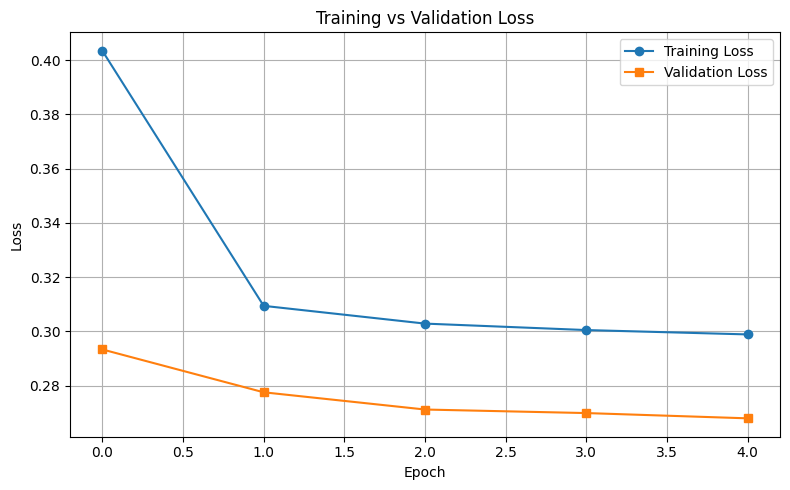

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Sample predictions
print("\nSample POS predictions with BERT:\n")
samples = test_data[:2]
model.eval()

with torch.no_grad():
    for i, (tokens, true_tags) in enumerate(samples):
        enc = tokenizer(tokens, is_split_into_words=True, return_tensors="pt",
                        padding="max_length", max_length=MAX_LEN, truncation=True)
        enc = {k: v.to(device) for k, v in enc.items()}
        out = model(enc["input_ids"], enc["attention_mask"]).argmax(dim=-1).squeeze().tolist()
        word_ids = tokenizer(tokens, is_split_into_words=True, max_length=MAX_LEN,
                             padding="max_length", truncation=True).word_ids()
        print(f"\nSentence {i+1}: {' '.join(tokens)}\n")
        print(f"{'Token':15s} → {'Predicted':12s} | {'True'}")
        print("-" * 50)
        for token, wid, pred in zip(tokenizer.convert_ids_to_tokens(enc["input_ids"][0]), word_ids, out):
            if wid is not None and wid < len(true_tags):
                print(f"{tokens[wid]:15s} → {id2pos[pred]:12s} | {true_tags[wid]}")
        print("=" * 50)


Sample POS predictions with BERT:


Sentence 1: no it was n't black monday

Token           → Predicted    | True
--------------------------------------------------
no              → INTJ         | INTJ
it              → PRON         | PRON
was             → AUX          | AUX
n't             → PART         | PART
n't             → PART         | PART
n't             → PART         | PART
black           → ADJ          | ADJ
monday          → PROPN        | PROPN

Sentence 2: but while the new york stock exchange did n't fall apart friday as the dow jones industrial average plunged N points most of it in the final hour it barely managed to stay this side of chaos

Token           → Predicted    | True
--------------------------------------------------
but             → CCONJ        | CCONJ
while           → SCONJ        | SCONJ
the             → DET          | DET
new             → PROPN        | PROPN
york            → PROPN        | PROPN
stock           → PROPN        | PROPN
excha

In [ ]:
print(model)

BERT_POS(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=T

In [ ]:
print("Parameter training status:\n")
for name, param in model.named_parameters():
    print(f"{name:60s} | requires_grad = {param.requires_grad}")

Parameter training status:

bert.embeddings.word_embeddings.weight                       | requires_grad = False
bert.embeddings.position_embeddings.weight                   | requires_grad = False
bert.embeddings.token_type_embeddings.weight                 | requires_grad = False
bert.embeddings.LayerNorm.weight                             | requires_grad = False
bert.embeddings.LayerNorm.bias                               | requires_grad = False
bert.encoder.layer.0.attention.self.query.weight             | requires_grad = False
bert.encoder.layer.0.attention.self.query.bias               | requires_grad = False
bert.encoder.layer.0.attention.self.key.weight               | requires_grad = False
bert.encoder.layer.0.attention.self.key.bias                 | requires_grad = False
bert.encoder.layer.0.attention.self.value.weight             | requires_grad = False
bert.encoder.layer.0.attention.self.value.bias               | requires_grad = False
bert.encoder.layer.0.attention.output

##<font color='blue'>----------**END**-----------</font>